# Doughnut of Social and Planetary Boundaries - Romain Gazon (8230028)

In a [recent paper in Nature](https://www.nature.com/articles/s41586-025-09385-1), Andrew L. Fanning and Kate Raworth examined the progress—or lack thereof—in meeting the needs of all people within the limits of the living planet.

To do this, they used a set of `35 indicators` that track `global` trends in `social deprivation` and `ecological overshoot` over the `2000–2022` period.

In this assignment, we will attempt to recreate some of their results and interpret them using the same datasets that they used in their research. 

In [1]:
import pandas as pd

In [2]:
data_path = r"a-fanning-doughnut-v3-a0460e5\Analysis-Final\cleanData\\"

eco_files = [
    "eco-1_climateChange_clean.csv",
    "eco-2_oceanAcid_clean.csv",
    "eco-3_chemPollution_clean.csv",
    "eco-4_nutrientPollution_clean.csv",
    "eco-5_freshwaterDisruption_clean.csv",
    "eco-6_landConversion_clean.csv",
    "eco-7_biodiversityBreakdown_clean.csv",
    "eco-8_airPollution_clean.csv",
    "eco-9_ozoneDepletion_clean.csv",
]

soc_files = [
    "soc-1_food_clean.csv",
    "soc-2_health_clean.csv",
    "soc-3_education_clean.csv",
    "soc-4_incomeWork_clean.csv",
    "soc-5_water_clean.csv",
    "soc-6_energy_clean.csv",
    "soc-7_connectivity_clean.csv",
    "soc-8_housing_clean.csv",
    "soc-9_equality_clean.csv",
    "soc-10_socialCohesion_clean.csv",
    "soc-11_politicalVoice_clean.csv",
    "soc-12_peaceJustice_clean.csv",
]

#ecological indicators dataset
eco_df = pd.concat([pd.read_csv(data_path + f) for f in eco_files], ignore_index=True)
#social indicators dataset
socio_df = pd.concat([pd.read_csv(data_path + f) for f in soc_files], ignore_index=True)

## The Social Foundation and Its Indicators of Shortfall

They attempted to measure global trends in human deprivation by monitoring `21 social indicators` across `12 dimensions`, spanning from complex social factors, such as social cohesion, to basic human rights like water, food and education. The range of each indicator is from 0 to 100% and each percent point represents 1% of the population whose needs are not currently being met.

The socio dataset requires additional preprocessing, as it includes indicators reported at both global and national levels.
To ensure consistency in the analysis, the data should be filtered based on the group column, retaining only global-level observations.

In [3]:
socio = socio_df.copy()
socio = socio[(socio['group'] == 'World')]

To avoid storing unnecessary data, we will drop all columns that are not listed in the assignment sheet `Table 1`. Additionally, we will need to handle `missing values`.

In [4]:
#drop unnecessary columns
socio = socio.drop(columns=[ 'group', 'populationTotal', 'GNIperCap', 'domain'])
socio.isna().sum()

dimension     0
indicator     0
date          0
value        98
dtype: int64

As we can see above, the column `value` appears to contain missing data. However, since this column stores the values of indicators for each year for which we have no reliable way of approximating them, we will simply drop them .

In [5]:
#drop missing values
socio = socio[socio['value'].notna()]

To obtain the desired result, we only need the columns `dimension`, `indicator`, `date`, and `value` for the years `2000` and `2022`. The easiest way to achieve this—while producing the final layout with two subcolumns under `date` and `value`—is by using `groupby`.

In [6]:
table_1 = (
    socio.sort_values('date')
       .groupby(['dimension', 'indicator'])
       .agg({ 
           #Calculate the first and last values for the date and value columns
           'date': ['first', 'last'],
           'value': ['first', 'last']
       })
)

In [7]:
table_1 = table_1.reset_index()

Finally, before showing the final result, we need to address some differences in values in the value columns. This is not an error from improperly wrangled or "bad" data", but a way of calculating these indicators. Specifically, for the Connectivity, Education, Energy and Water dimensions, the data calculates the percentage of the population that has access to the internet, electricity, clean fuels, water, etc., while we want it expressed as the percentage of people lacking access. As such, we will recalculate the values for these dimensions as: value = 100 − value. As for the Equality dimension and the Societal Poverty indicator, the values are measured on a scale of 0 to 1, so in order to express them as percentages we will multiply those values by 100.

In [8]:
table_1.loc[table_1['dimension'].isin(['connectivity', 'education', 'energy', 'water']), 'value'] = (
    (100 - table_1.loc[table_1['dimension'].isin(['connectivity', 'education', 'energy', 'water']), 'value'])
).values

table_1.loc[table_1['dimension'] == 'equality', 'value'] = (
    (table_1.loc[table_1['dimension'] == 'equality', 'value'] * 100)
).values

table_1.loc[table_1['indicator'] == 'societalPoverty', 'value'] = (
    (table_1.loc[table_1['indicator'] == 'societalPoverty', 'value'] * 100)
).values

In [9]:
table_1 = table_1.round(2) # use two decimals like in assignment sheet

In [10]:
#map indicators with their extended labels values to match assignment table
social_indicators = {
    "internet":          "Population not accessing the internet",
    "publicTrans":       "Urban population lacking convenient access to public transport",
    "adultLiteracy":     "Adult population (aged 15+ years) who are illiterate",
    "secondarySchool":   "Young adult population (aged 21-23 years) with incomplete upper secondary education",
    "energyAccess":      "Population lacking access to electricity",
    "energyIndoor":      "Population lacking access to clean fuels and technologies for cooking, heating and lighting",
    "genderGapIndex":    "Population-weighted score on the Gender Inequality Index",
    "foodInsecurity":    "Population with moderate to severe food insecurity",
    "undernourishment":  "Population undernourished",
    "UHCindex":          "Population living in countries without high coverage of essential health services (UHC Index score less than 60)",
    "under5death":       "Population living in countries with under-5 mortality rate exceeding 25 per 1,000 live births",
    "urbanSlums":        "Urban population living in slums or informal settlements",
    "societalPoverty":   "Population living below the societal poverty line",
    "youthNEET":         "Population of young people (aged 15-24 years) not in employment, education or training",
    "controlCorruption": "Population stating that they perceive widespread corruption in government and business",
    "homicideOver5":     "Population living in countries with a homicide rate of 5 or more per 100,000",
    "govRegimes":        "Population living in countries governed by an autocratic regime",
    "palma":             "Population living in countries with a Palma ratio of 2 or more",
    "socialSupport":     "Population stating that they are without someone to count on in times of trouble",
    "drinkingH2O":       "Population lacking access to safely managed drinking water",
    "sanitation":        "Population lacking access to safely managed sanitation",
}

table_1['indicator'] = table_1['indicator'].map(social_indicators)
table_1['dimension'] = table_1['dimension'].str.capitalize()

The final table is displayed, formatted to match the assignment sheet, followed by a short summary of the findings (we create a function for leeter repurpose for table 2).

In [11]:
def display_table(df):
    display(
        df.style
        .hide(axis="index")
        .format("{:.2f}", subset=[("value", "first"), ("value", "last")])
        .format("{:.0f}", subset=[("date", "first"), ("date", "last")])
        .set_properties(subset=[("indicator", "")], **{
            "white-space": "normal",
            "max-width": "320px",
            "text-align": "left"
        })
        .set_properties(subset=[("dimension", "")], **{
            "text-align": "left"
        })
        .set_table_styles([
            {"selector": "th", "props": [("font-weight", "bold"), ("text-align", "center"), ("border", "1px solid #ccc")]},
            {"selector": "td", "props": [("border", "1px solid #ccc"), ("padding", "6px 10px")]},
            {"selector": "th.col_heading.level0", "props": [("text-align", "center"), ("border-bottom", "1px solid #ccc")]},
        ])
    )

display_table(table_1)

A quick observation from the table is that, from `2000` to `2022`, most social indicators improved. The average percentage across indicators was `48.57` in `2000` and `35.21` in `2022`, in other words a shortfall of `13%` which means that approximately `13%` fewer people are affected by the average indicator. This overall decline indicates broad global progress across several social dimensions, particularly in areas related to basic services and living conditions (e.g. Energy).

More specifically, there was an average improvement of `17.5%` (or `0.795%` improvement on average per year) for the `17` out of `21` indicators that improved. Many of these improvements are associated with increased access to infrastructure, education, and health services.

However, for the indicators that worsened—`Population stating that they are without someone to count on in times of trouble`, `Population living in countries governed by an autocratic regime`, and `Population with moderate to severe food insecurity`—there was an average increase of `11.26%` (`0.489%` per year), suggesting that `social cohesion`, `political freedom`, and `food security` remain important challenges despite the overall progress.

## The Ecological Ceiling and Its Indicators of Overshoot

We will continue with the 14 ecological indicators which are based on nine planetary boundaries (dimensions) designed to prevent catastrophic environmental damage. Each boundary/dimension is measured on a different scale and has a different threshold (overshoot zone). For example concentration of co2 has a threshold of 350 ppm (part per million) while extionction rate has 10 species lost per million per year.

In [12]:
eco = eco_df.copy()

Like previously, the eco dataset the data will be filtered based on the group column in order to retain only global-level observations.

In [13]:
eco = eco[(eco['group'] == 'World') & (eco['type'] == 'global doughnut')]
# drop unnecessary columns
eco = eco.drop(columns=['type', 'group', 'populationTotal', 'GNIperCap', 'domain'])

In [14]:
# see state of missing values
eco.isna().sum()

dimension     0
indicator     0
date          0
value        70
dtype: int64

Like with the social indicators, rows with missing values in the value column should be removed since they cannot be approximated.

In [15]:
eco = eco[eco['value'].notna()]

In [16]:
table_2 = (
    eco.sort_values('date')
       .groupby(['dimension', 'indicator'])
       .agg({
           'date': ['first', 'last'],
           'value': ['first', 'last']
       })
)

In [17]:
table_2 = table_2.round(2) #to match the assignment sheet
table_2.reset_index(inplace=True)

As observed below, there is a chemical pollution indicator which refers to the share of EU chemical pollution (EUshare_hzdHealth). This does not align with the global scope required for the analysis. Therefore, this row should be removed from the dataset.

In [18]:
table_2[table_2['indicator'] == 'EUshare_hzdHealth']

dimension          indicator  date        value       
                                         first  last  first   last
3  chemical pollution  EUshare_hzdHealth  2000  2022  76.59  76.59

In [19]:
table_2 = table_2[table_2['indicator'] != 'EUshare_hzdHealth']

Lastly, to ensure consistency with the assignment sheet, the values in the indicator column must be replaced with the appropriate descriptive names of the corresponding indicators used in the analysis. Additionally, dimension names will be changed to start with capital letters to also ensure consistency with the assignment sheet.

In [20]:
ecological_indicators = {
    'interhemAOD': "Arithmetic Error Asymmetry between Earth's hemispheres of sunlight reaching the surface, owing to differences in atmospheric particle concentration (at most 0.1 inter-hemispheric difference in Aerosol Optical Depth)",
    'extinction1900': "Rate of species extinctions per million species years (at most 10 E/MSY)",
    'hanppGtC': "Human appropriation of net primary productivity, billions of tonnes of carbon per year (at most 10% of 55.9 Gt C)",
    'chemicalsMt': "Production of hazardous chemicals, millions of tonnes per year (at most 5% of the 1,200 Mt of total chemicals produced in year 2000)",
    'co2_ppm': "Atmospheric carbon dioxide concentration, parts per million (at most 350 ppm CO2)",
    'erf_wm2': "Human-induced radiative forcing at the top of the atmosphere, Watt per square metre (at most 1 W m**(-2))",
    'blueDev': "Proportion of land area with human-induced disturbance of blue-water flow deviating from Holocene variability (at most 10.2%)",
    'soilDev': "Proportion of land area with root-zone soil moisture deviating from Holocene variability (at most 11.1%)",
    'forestAreaMKM2': "Area of forested land as a proportion of forest-covered land before human alteration (at least 75% of 64 million square kilometres)",
    'nitrogenMt': "Nitrogen applied to land as fertilizer, millions of tonnes per year (at most 62 Mt per year)",
    'phosphorusMt': "Phosphorus applied to land as fertilizer, millions of tonnes per year (at most 6.2 Mt per year)",
    'omega_a': "Average saturation state of aragonite at the ocean surface (at least 80% of pre-industrial saturation state of 3.44 Ωarag)",
    'totalOzone': "Concentration of ozone in the stratosphere, Dobson units (at most 5% decrease with respect to 1964-1980 value of 290 DU)",
}

table_2['indicator'] = table_2['indicator'].map(ecological_indicators)
table_2['dimension'] = table_2['dimension'].str.capitalize()

The final table is displayed, formatted to match the assignment sheet, followed by a short summary of the findings.

In [21]:
display_table(table_2)

Before summarizing the findings, it is important to note that not all indicators are tracked until 2022. However, most are tracked until 2020 or later, with only three indicators ending earlier. Overall, the results suggest a worsening environmental situation. In 2000, 9 out of 13 indicators had already exceeded their safe limits, and they continue to exceed them in the most recent year available.

On average, ecological indicators changed by about 17.2% between 2000 and their latest recorded value, indicating a general deterioration in environmental pressures. Among the indicators that exceed their planetary boundaries, the average exceedance is about 624%, although this figure is strongly influenced by extreme outliers. In particular, chemical pollution and species extinction are approximately 37 and 10 times above their safe limits, respectively.

Notably, the indicators that remained within their safe boundaries in 2000 (Ozone depletion, Air pollution, Freshwater disruption and ocean acidification) are still within them today. This may suggest that effective international regulation or coordinated global action—such as policies addressing ozone depletion— are in place.

## Country Clusters

In this section we will reate a trellis plot that displays the ecological overshoot and one that displays the social shorfall, for each indicator, for countries grouped according to their wealth (bottom-40, middle-40, top-20).

In [22]:
import matplotlib
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
panel_data = pd.read_csv(r'a-fanning-doughnut-v3-a0460e5\Analysis-Final\myData\5_20250108_doughnutDat-boundariesRatios.csv')

We will use the `2017` indicator values, as this is the only year in which all indicator shortfalls/overshoots are available. The sole exception is `Lack of Public Transport`, for which we will use the `2020` values, as it is the closest year with recorded data.

In [53]:
panel_data = panel_data[((panel_data['date'] == 2017) & (panel_data['indicator'] != 'publicTrans')) |
                         ((panel_data['date'] == 2020) & (panel_data['indicator'] == 'publicTrans'))]

We will retain only the necessary data. Specifically, data related to ecological overshoot or social shortfall for countries grouped by wealth (`Bottom 40`, `Middle 40`, `Top 20`). Additionally, we will remove the `racialInequality` indicator, as it contains only missing values.

In [54]:
panel_data = panel_data[panel_data['type'] == 'national aggregate']
panel_data = panel_data[panel_data['group']!='World']
panel_data = panel_data[panel_data['indicator'] != 'racialInequality']

In [55]:
panel_data.reset_index(drop=True, inplace=True)

In [56]:
#map indicators like previously to match assignment sheet form
panel_indicator_map = {
    'UHCindex': 'Lack of health services',
    'adultLiteracy': 'Illiteracy rate',
    'controlCorruption': 'Perceptions of corruption',
    'drinkingH2O': 'Unsafe drinking water',
    'energyAccess': 'Lack of electricity',
    'energyIndoor': 'Lack of clean fuels indoors',
    'foodInsecurity': 'Food insecurity',
    'genderGapIndex': 'Gender inequality',
    'govRegimes': 'Autocratic regimes',
    'homicideOver5': 'Homicide rate',
    'internet': 'Lack of internet',
    'palma': 'Income inequality',
    'publicTrans': 'Lack of public transport',
    'sanitation': 'Unsafe sanitation',
    'secondarySchool': 'Incomplete secondary school',
    'socialSupport': 'Lack of social support',
    'societalPoverty': 'Societal poverty',
    'under5death': 'Under-5 mortality',
    'undernourishment': 'Undernourished',
    'urbanSlums': 'Slums or informal housing',
    'youthNEET': 'Youth NEET',
    'N_footprint': 'Nitrogen footprint',
    'P_footprint': 'Phosphorus footprint',
    'blueH2O_footprint': 'Blue water footprint',
    'co2_footprint': 'Carbon footprint',
    'hanpp_footprint': 'HANPP footprint',
    'species_footprint': 'Species-loss footprint'
}

panel_data = panel_data[panel_data['indicator'].isin(panel_indicator_map.keys())]
panel_data['indicator'] = panel_data['indicator'].map(panel_indicator_map)

In [57]:
panel_data = panel_data[['domain', 'indicator', 'type', 'group', 'value', 'boundary', 'ratio']]

In [60]:
panel_data.head()

,domain,indicator,type,group,value,boundary,ratio
0,ecological,Carbon footprint,national aggregate,Bottom-40,0.938904,0.95,0.988320
1,ecological,Carbon footprint,national aggregate,Middle-40,4.256704,0.95,4.480741
2,ecological,Carbon footprint,national aggregate,Top-20,11.650509,0.95,12.263694
9,ecological,Nitrogen footprint,national aggregate,Bottom-40,10.597806,8.50,1.246801
10,ecological,Nitrogen footprint,national aggregate,Middle-40,21.440116,8.50,2.522367


### Ecological Overshoot Trellis Plot

We will now focus on creating the ecological overshoot trellis plot.

In [61]:
eco_short = panel_data[panel_data['domain'] == 'ecological'].copy()

The ratio must be reformatted for our purposes. Currently, it represents an indicator’s value relative to its planetary boundary (e.g., a ratio of `0.98` means the indicator is at 98% of the boundary). However, we want the ratio to reflect the extent of overshoot relative to the planetary boundary (e.g., a ratio of `0.98` indicating that the boundary is exceeded by 98% of its value).

To achieve this, we will subtract `1` from every value in the `ratio` column.

In [62]:
eco_short['ratio'] = eco_short['ratio'] - 1

In [63]:
# sort values in alphabetcial order by ind and group to match the assignment sheet
eco_short.sort_values(['indicator', 'group'], inplace=True)

In [64]:
eco_short = eco_short.groupby(['indicator', 'group'])['ratio'].sum().reset_index()
eco_short.head()

,indicator,group,ratio
0,Blue water footprint,Bottom-40,-0.460627
1,Blue water footprint,Middle-40,-0.575454
2,Blue water footprint,Top-20,-0.304410
3,Carbon footprint,Bottom-40,-0.011680
4,Carbon footprint,Middle-40,3.480741


The ratio is currently expressed on a scale from `0` to `1`. However, for the purposes of this assignment, we want it in percentages; therefore, we will multiply it by `100`.

In [65]:
eco_short['overshoot_perc'] = eco_short['ratio'] * 100

In [66]:
palette = ['#fad516', '#d8bfd8', '#4682b4'] #used for both trellis plots

To match the trellis plot specified in the assignment, we will:

1. Hide the y-axis for all plots except those in the leftmost column, keeping a single shared reference scale (0 to 1000).
2. Hide the x-axis for all plots except those in the top row.
3. Move the x-axis to the top for the top-row plots to match the required layout.

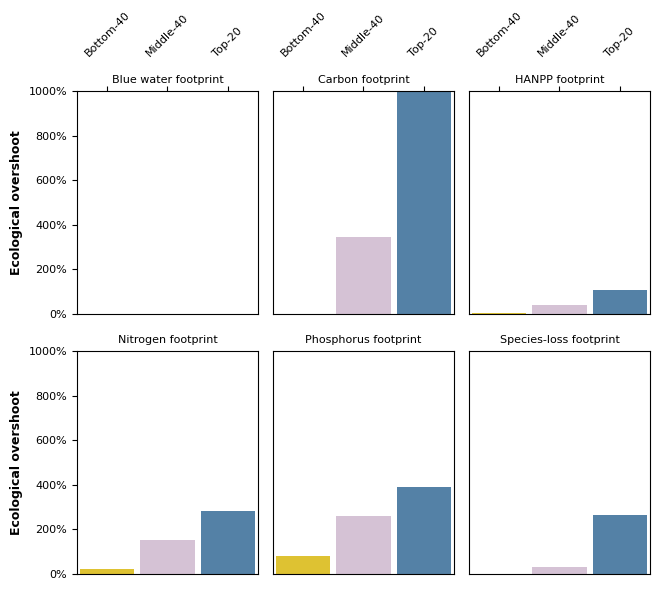

In [67]:
indicators2 = eco_short['indicator'].unique()

n_cols = 3
n_rows = -(-len(indicators2) // n_cols)

fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(6.7, 6))
axes2 = axes2.flatten()

for i, indicator in enumerate(indicators2):
    ax = axes2[i]
    data2 = eco_short[eco_short['indicator'] == indicator]
    if i % 3 != 0: #only keep leftest y axes
        ax.yaxis.set_visible(False)
    else:
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.tick_params(axis='y', labelsize=8)
        ax.set_ylabel('Ecological overshoot', fontweight='bold', fontsize=9)

    sns.barplot(data=data2, x='group', y='overshoot_perc', hue='group', width=0.9, palette=palette, legend=False, ax=ax)
    ax.set_ylim(0, 1000)
    ax.set(xlabel=None)

    if i < n_cols:
        ax.xaxis.set_ticks_position('top')
        ax.tick_params(axis='x', rotation=45, pad=20, labelsize=8)
        ax.set_title(indicator, fontsize=8, y=1)
    else:
        ax.set_title(indicator, fontsize=8)
        #only keep top line x-axes.
        ax.xaxis.set_visible(False)

plt.tight_layout()
plt.show()

For the six indicators visualized, a clear pattern emerges: the richer the country group, the greater the ecological overshoot. The only exception is the `Blue Water Footprint`, where—despite values not being visible due to scale limits—the `Middle 40` appears closer to the planetary boundary than the `Bottom 40` (-46% compared to -57%).

Finally, the `Bottom 40` is the only group that remains consistently below or only slightly above the planetary boundary. This may be associated with lower levels of economic activity and industrialization, although this relationship cannot be confirmed from the visualization alone.

### Social Shootfall

We will continue with the social shortfall trellis plot.

In [74]:
social_short = panel_data[panel_data['domain'] == 'social']

In [75]:
soc_chart = social_short.groupby(['indicator', 'group'])['ratio'].sum().reset_index()

In [76]:
soc_chart.head(3)

,indicator,group,ratio
0,Autocratic regimes,Bottom-40,0.166064
1,Autocratic regimes,Middle-40,0.321569
2,Autocratic regimes,Top-20,0.934024


As before, we need to reformat the `ratio` column. Currently, it represents the share of people *not* affected by an indicator (e.g., a value of `0.16` for autocratic regimes means that 16% of the group is unaffected).

To express the percentage of people *affected*, we will subtract each value from `1` (the maximum possible value) and then multiply the result by `100`.

In [77]:
soc_chart['undershoot_perc'] = (1 - soc_chart['ratio']) * 100

In [78]:
soc_chart.sort_values(['indicator', 'group'], inplace=True)

Finally, to match the assignment sheet, we will:

1. Invert the y-axis to match the desired visual orientation.
2. Hide the y-axis for all plots except those in the leftmost column, maintaining a shared reference scale (`0` to `100`).
3. Hide the x-axis for all plots except those in the bottom row.

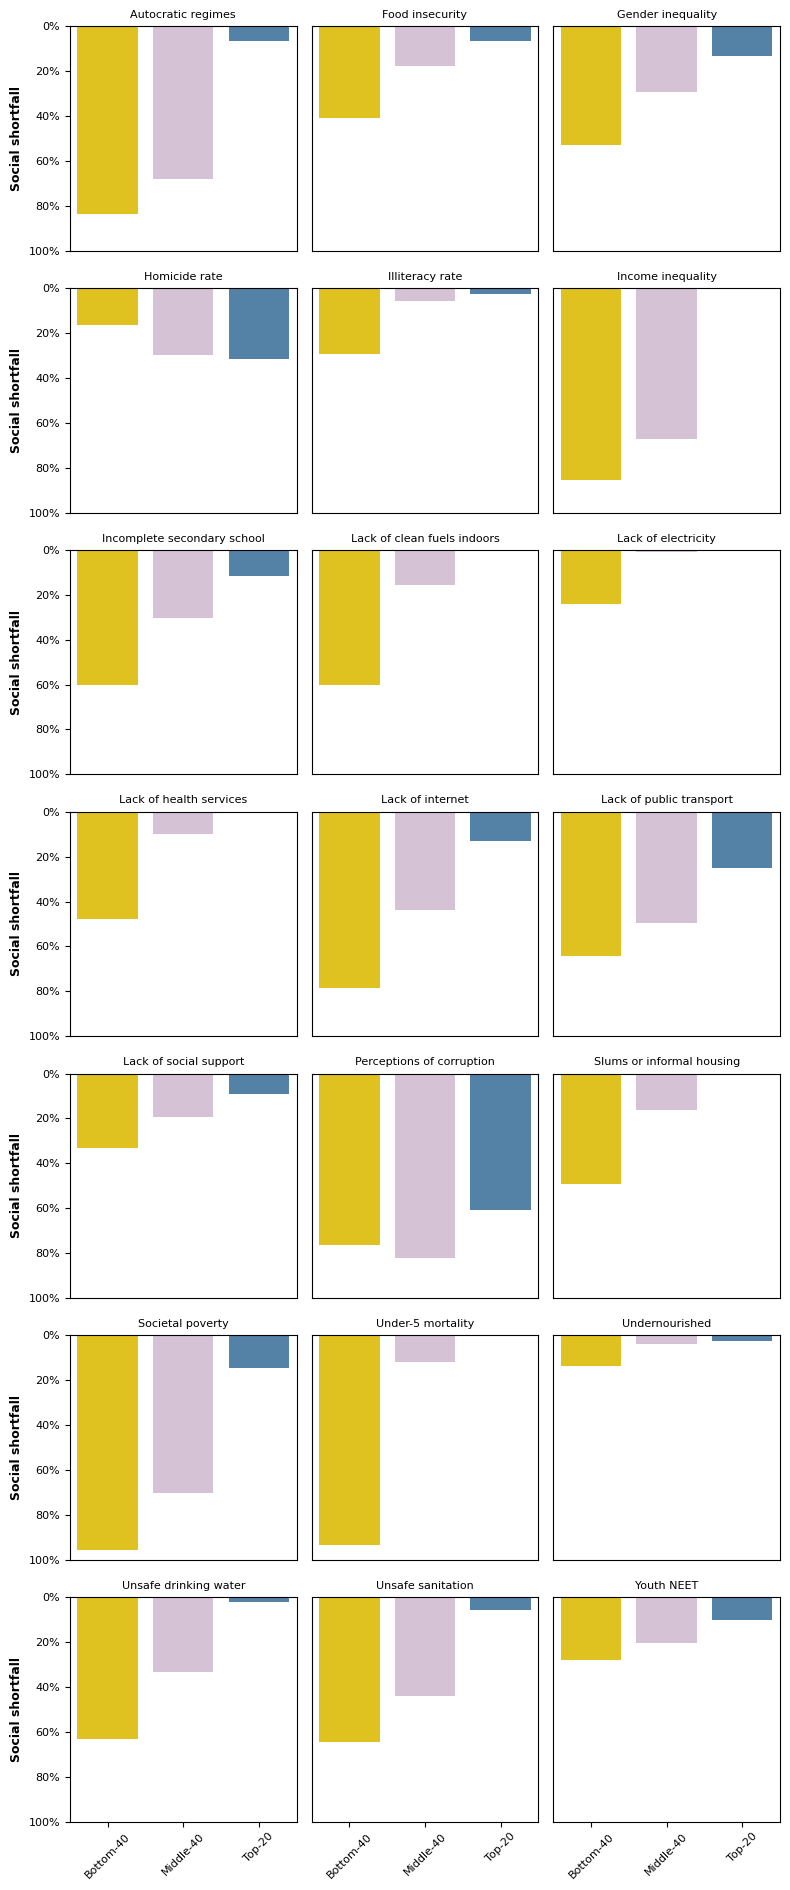

In [80]:
indicators = soc_chart['indicator'].unique()

n_cols = 3
n_rows = -(-len(indicators) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8, 19))
axes = axes.flatten()

for i, indicator in enumerate(indicators):
    ax = axes[i]
    data = soc_chart[soc_chart['indicator'] == indicator]
    
    if i % 3 != 0 :
        ax.yaxis.set_visible(False)
    else :
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.set_ylabel('Social shortfall', fontweight='bold', fontsize=9)
    
    sns.barplot(data=data, x='group', y='undershoot_perc', hue='group', palette=palette, legend=False, ax=ax)
    ax.set_title(indicator, fontsize=8)
    ax.set_ylim(0, 100)
    ax.invert_yaxis()
    ax.set(xlabel=None)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

for ax in axes[:-3]:
    ax.xaxis.set_visible(False)
    
    
plt.tight_layout()
plt.show()

From the social indicators depicted, a pattern similar to the ecological case emerges: the poorer the country group, the greater the social challenges. The only true exceptions are `Homicide Rate`, which shows the opposite trend, and `Perceptions of Corruption`, where the `Bottom 40` reports lower levels than the `Middle 40`.

The `Top 20` is the only group that consistently displays low to no social shortfall. In particular, basic needs (measured through indicators such as `Food Insecurity` and `Access to Electricity`) appear to be largely met, with some remaining room for improvement in areas such as corruption and the previously mentioned `Homicide Rate`.

It should also be noted that `Perceptions of Corruption` are relatively high across all groups and, as shown in Table 2, a large share of people report widespread corruption in their country.

The overall picture from both trellis plots suggests that the richer the country group, the greater its contribution to ecological overshoot, while at the same time experiencing fewer social challenges. This trade-off has been widely discussed in the literature, with various explanations proposed. These include historical factors such as colonialism, as well as the idea that wealthier countries tend to have more established institutions and governance structures, which may contribute to better social outcomes.

At the same time, higher levels of economic activity and consumption in these countries are often associated with increased pressure on ecological systems. While these patterns are clearly reflected in the data, the underlying causes fall outside the scope of the assignment and are complex and cannot be fully determined from this analysis alone.

## SANDWICH PLOT

In this section, we will visualize the `sandwich plot`, which displays the `first` and `last` recorded `social shortfall` and `ecological overshoot` for every documented indicator.

In [82]:
sandwich = pd.read_csv(r'a-fanning-doughnut-v3-a0460e5\Analysis-Final\myData\12_20250515_globalDoughnutData_2000-2022.csv')

In [83]:
print(sandwich['type'].unique())
print(sandwich['group'].unique())

['global doughnut']
['World']


We will only keep the data needed for the analysis. Since the `group` and `type` columns each contain only one value, we will drop them. Additionally, the value of `boundary` column is not needed, as the overshoot and shortfall values are already captured in the `shortfallOvershoot_pct` column.

In [85]:
sandwich = sandwich[['domain', 'dimension', 'indicator', 'date', 'shortfallOvershoot_pct' ]]

As with the previously used datasets, the `racialInequality` indicator should be removed, as it contains only missing values.

In [87]:
sandwich = sandwich[sandwich['indicator'] != 'racialInequality']

We will only keep the `first` and `last` recorded dates.

In [89]:
sandwich.sort_values(['indicator', 'date'], inplace=True)

#filter dataset to include only these dates
for indicator in sandwich['indicator'].unique() :
    earliest_value, early_date = sandwich.loc[
        (sandwich['indicator'] == indicator) & sandwich['shortfallOvershoot_pct'].notna()
    ].sort_values('date')[['shortfallOvershoot_pct', 'date']].iloc[0]
    # all indicators have values for 2022 (last date for dataset)
    sandwich = sandwich[~((sandwich['indicator'] == indicator) & (sandwich['date'] != early_date) & (sandwich['date'] != 2022))]

In [90]:
# use map to have the same indicator names with those in assignment sheet
indicator_map = {
    "govRegimes": "Autocratic regimes",
    "under5death": "Child mortality",
    "foodInsecurity": "Food insecurity",
    "genderInequalityIndex": "Gender inequality",
    "homicideOver5": "Homicides",
    "adultLiteracy": "Illiteracy",
    "urbanSlums": "Inadequate housing",
    "palma": "Income inequality",
    "secondarySchool": "Incomplete secondary school",
    "energyIndoor": "Lack of clean fuels indoors",
    "energyAccess": "Lack of electricity",
    "UHCindex": "Lack of health services",
    "internet": "Lack of internet",
    "publicTrans": "Lack of public transport",
    "socialSupport": "Lack of social support",
    "controlCorruption": "Perceptions of corruption",
    "societalPoverty": "Societal poverty",
    "undernourishment": "Undernourishment",
    "drinkingH2O": "Unsafe drinking water",
    "sanitation": "Unsafe sanitation",
    "youthNEET": "Youth unemployment",
    
    "interhemAOD": "Aerosol optical depth",
    "omega_a": "Aragonite saturation",
    "blueDev": "Blue-water flows",
    "co2_ppm": "CO2 concentration",
    "forestAreaMKM2": "Forest area",
    "chemicalsMt_Hzd": "Hazardous chemicals production",
    "hanppGtC": "Human appropriation of energy production",
    "nitrogenMt": "Nitrogen pollution",
    "phosphorusMt": "Phosphorus pollution",
    "erf_wm2": "Radiative forcing",
    "soilDev": "Soil moisture",
    "extinction1900": "Species extinctions",
    "totalOzone": "Stratospheric ozone concentration"
}

sandwich['indicator'] = sandwich['indicator'].map(indicator_map)

We will replace the values in the `date` column with `'first'` and `'last'`, since these values will be used to create new columns. As not all end values are from 2022, this approach improves readability.

In [92]:
sandwich['date'] = sandwich['date'].astype(str)
sandwich.loc[sandwich['date'] == '2022', 'date'] = 'last'
sandwich.loc[sandwich['date'] != 'last', 'date'] = 'first'

We will create two separate dataframes — one for `ecological` indicators and one for `social` indicators — primarily to improve readability.

In [94]:
eco_sand = (
    sandwich[sandwich['domain'] == 'ecological'].pivot_table(index='indicator', columns='date', values='shortfallOvershoot_pct')
    .reset_index()
)
eco_sand.columns.name = None

social_sand = (
    sandwich[sandwich['domain'] == 'social'].pivot_table(index='indicator', columns='date', values='shortfallOvershoot_pct')
    .reset_index()
)
social_sand.columns.name = None

To create the desired visualization, we will stack bar plots on top of one another. Unlike the ecological indicators — where all values are greater at the end than at the beginning, allowing us to simply layer one bar plot behind the other — the social indicators have mixed results.

To account for this, we need to adjust our visualization logic. We will first identify the greater value for each row. The smaller value will always be displayed in the same color, while the greater value will be colored differently depending on whether it corresponds to the `first` or `last` recorded value. Light bars indicate a reduction in shortfall or overshoot, while dark bars indicate an increase between the start and end periods.

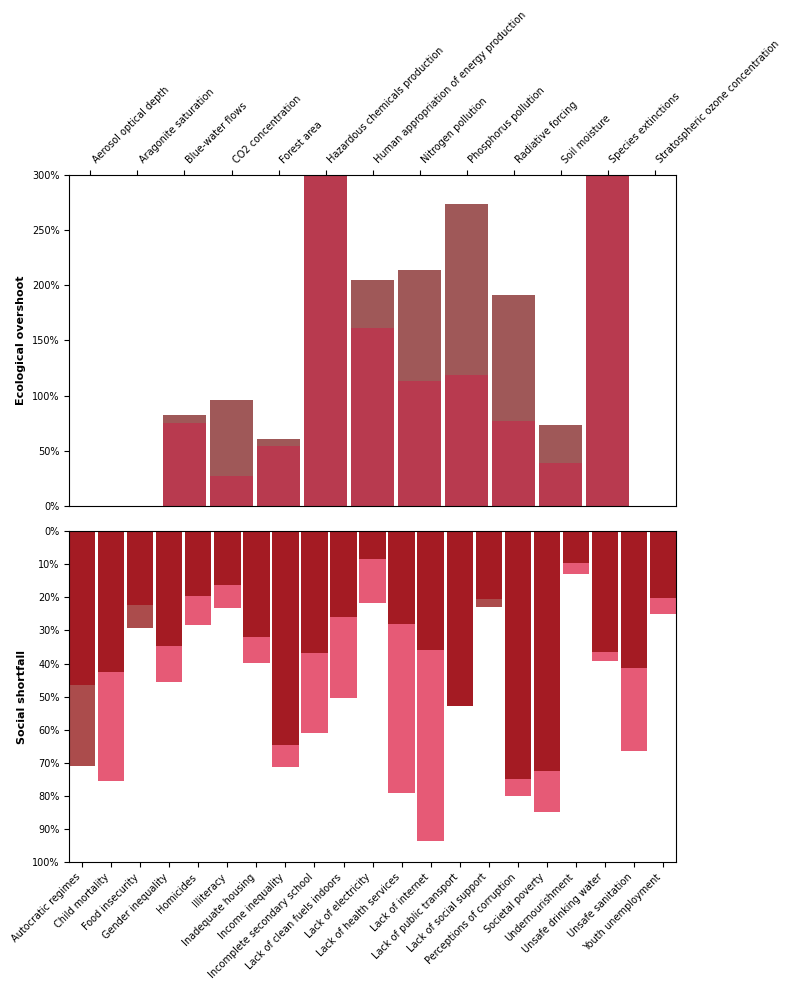

In [96]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))

#ecological overshoot plot
sns.barplot(x='indicator', y='last', data=eco_sand, color='#ab4c4c', ax=ax1, width=0.9)
sns.barplot(x='indicator', y='first', data=eco_sand, color='#cd2541', ax=ax1, width=0.9)
ax1.set_xlabel('')
ax1.set_ylabel('Ecological overshoot', fontweight='bold', fontsize=8)
ax1.xaxis.tick_top()
ax1.tick_params(axis='x', labelrotation=45, labelsize=7)
ax1.tick_params(axis='y', labelsize=7)
plt.setp(ax1.get_xticklabels(), ha='left')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.set_ylim(0, 300)
ax1.margins(x=0)

#social shortfall plot
for _, row in social_sand.iterrows():
    if row['first'] > row['last']:
        ax2.bar(row['indicator'], row['first'], color='#e65a76', width=0.9)
        ax2.bar(row['indicator'], row['last'], color='#a41b23', width=0.9)
    else:
        ax2.bar(row['indicator'], row['last'], color='#ab4c4c', width=0.9)
        ax2.bar(row['indicator'], row['first'], color='#a41b23', width=0.9)

ax2.set_xlabel('')
ax2.set_ylabel('Social shortfall', fontweight='bold', fontsize=8)
ax2.tick_params(axis='x', labelrotation=45, labelsize=7)
ax2.tick_params(axis='y', labelsize=7)
plt.setp(ax2.get_xticklabels(), ha='right')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.yaxis.set_major_locator(mtick.MultipleLocator(10))
ax2.set_ylim(100, 0)
ax2.margins(x=0)

plt.tight_layout()
plt.show()

The implications of this visualization are consistent with those from Table 1 and Table 2, but are more clearly communicated, as the bar chart format is easier to interpret than a tabular one.

Regarding the ecological indicators, the situation has clearly worsened: no indicator shows improvement, and only `Aerosol Optical Depth`, `Aragonite Saturation`, and `Stratospheric Ozone Concentration` remain below the planetary boundary.

The social dimension presents a more mixed picture. While some progress is evident, indicators such as `Autocratic Regimes`, `Food Insecurity`, and `Lack of Social Support` have deteriorated. Overall, the setbacks appear to outweigh the improvements, reinforcing the urgency of the challenges ahead.

## DOUGHNUT PLOT

We can use the same dataframes for the doughnut plot but we only need the lines where date equals 'last'.

The doughnut graph we want to create is some sort of pie/sunburst chart. Additionally, we want to create an interactive visualization. With that in mind we will attempt to create a final Dash product, which is supported by the plotly librairy.
However, plotly doesnt support the automatic creation of such complex visualizations and as such we will create it ourselves with the use of the polar chart librairy (https://plotly.com/python/polar-chart/), svg files created with Figma and by laying them on top of another.

In [100]:
import plotly.graph_objects as go
import numpy as np

In [101]:
sandwich.reset_index(drop=True, inplace=True)
sandwich.head()

,domain,dimension,indicator,date,shortfallOvershoot_pct
0,social,health,Lack of health services,first,79.1
1,social,health,Lack of health services,last,28.1
2,social,education,Illiteracy,first,23.1
3,social,education,Illiteracy,last,16.2
4,ecological,freshwater disruption,Blue-water flows,first,74.8


In [102]:
donut_eco = sandwich[(sandwich['domain'] == 'ecological') & (sandwich['date'] == 'last')].copy()

In the literature, like the Stockholm Resilience Centre and the Doughnut Economics Action Lab. (e.g. https://www.stockholmresilience.org/research/planetary-boundaries.html), the indicators (ecological and social) are ordered thematically to improve the clarity and readability of the visualization by placing related dimensions next to each other. To ensure consistency with relevant papers, documents...etc we will follow the literature sorting of the indicators

In [103]:
eco_order = [
    'CO2 concentration',
    'Radiative forcing',
    'Aragonite saturation',
    'Hazardous chemicals production',
    'Phosphorus pollution',
    'Nitrogen pollution',
    'Aerosol optical depth',
    'Blue-water flows',
    'Soil moisture',
    'Forest area',
    'Species extinctions',
    'Human appropriation of energy production',
    'Stratospheric ozone concentration',
]

donut_eco['indicator'] = pd.Categorical(donut_eco['indicator'], categories=eco_order, ordered=True)
donut_eco = donut_eco.sort_values('indicator').reset_index(drop=True)

In [104]:
social_eco = sandwich[(sandwich['domain'] == 'social') & (sandwich['date'] == 'last')].copy()

In [105]:
social_indicators = [
    'Undernourishment',
    'Food insecurity',
    'Child mortality',
    'Lack of health services',
    'Illiteracy',
    'Incomplete secondary school',
    'Societal poverty',
    'Youth unemployment',
    'Perceptions of corruption',
    'Homicides',
    'Autocratic regimes',
    'Lack of social support',
    'Income inequality',
    'Gender inequality',
    'Inadequate housing',
    'Lack of public transport',
    'Lack of internet',
    'Lack of electricity',
    'Lack of clean fuels indoors',
    'Unsafe drinking water',
    'Unsafe sanitation'
]

social_eco['indicator'] = pd.Categorical(social_eco['indicator'], categories=social_indicators, ordered=True)
social_eco = social_eco.sort_values('indicator').reset_index(drop=True)

For go.Barpolar, wedge area is equal to 0.5 × r² × width_in_radians.
As such for all polar plots our radius will be equal to the relevant value's square root and then divided by a constant so it fits approprierly in the space of the fig.

In [107]:
fig = go.Figure()

As it can be seen in the assignment sheet doughnut, each dimension is separated by white space. To achieve this look we will use the width and theta arguments of Barpolar. The rationale is the following: every indicator column will have the same width, but we will leave some whitespace around them by multiplying by 0.9. When done, out of 360 degrees, column space is equal to 360/13 * 0.9 * 13 = 324, then the total whitespace is 360 - 324 = 36 degrees, meaning each adjacent pair of bars has 36/13 = 2.769 degrees of space between them. To group dimensions together, theta will be used: for each indicator we check if the next indicator belongs to a different dimension, and if it does, we move that bar back by 2.769 degrees to create the wanted space.

In [108]:
#find theta values for outer/ecological bars
theta1 = np.linspace(0, 360, 13, endpoint=False)
for i in range(len(donut_eco['dimension'])):
    if donut_eco['dimension'][i] != donut_eco['dimension'][(i + 1) % 13]:
        theta1[i] = theta1[i] - 2.769

In [109]:
#ecological bars
fig.add_trace(go.Barpolar(
    r=[np.sqrt(max(v, 0))/3.5 for v in donut_eco['shortfallOvershoot_pct']],
    width=360/13 * 0.9,
    theta=theta1,
    marker=dict(
        color=donut_eco['shortfallOvershoot_pct'],
        #use of 0.28 in order for column colors to be too low due to huge value of the biggest column
        colorscale=[[0, '#ffc6c4'], [0.085, '#dd788c'], [0.28, '#aa446b'], [1, '#672044']],
        cmin=donut_eco['shortfallOvershoot_pct'].min(),
        cmax=donut_eco['shortfallOvershoot_pct'].max(),
        showscale=False,
    ),
    base=6,
    hovertext=donut_eco['indicator'],
    customdata=donut_eco['shortfallOvershoot_pct'],
    hovertemplate='%{hovertext}: %{customdata:.1f}%<extra></extra>',
    hoverlabel=dict(bgcolor='white', font_size=14),
    subplot='polar'
));

Creation of the three green circles:

In [111]:
#inner rings
fig.add_shape(type="circle", xref="paper", yref="paper", fillcolor="#227443", x0=0.3, y0=0.3, x1=0.7, y1=0.7, line_color="#227443", layer="below");
fig.add_shape(type="circle", xref="paper", yref="paper", fillcolor="#6eb446", x0=0.32, y0=0.32, x1=0.68, y1=0.68, line_color="#6eb446", layer="below");
fig.add_shape(type="circle", xref="paper", yref="paper", fillcolor="#227443", x0=0.37, y0=0.37, x1=0.63, y1=0.63, line_color="#227443", layer="below");
fig.add_shape(type="circle", xref="paper", yref="paper", fillcolor="#ffffff", x0=0.389, y0=0.389, x1=0.611, y1=0.611, line_color="#227443", layer="below");

We will use the same logic as before for the grouping of the social indicator bars.

In [112]:
#find theta values for inner/social bars
theta2 = np.linspace(0, 360, 21, endpoint=False)
for i in range(len(social_eco['dimension'])):
    if social_eco['dimension'][i] != social_eco['dimension'][(i + 1) % 21]:
        theta2[i] = theta2[i] - 1.713

We will once again use the Plotly Barpolar library to create the inner social chart. However, the "inwards-filling" look is not natively supported by the library, so we will simulate it by layering two Barpolar charts on top of one another. The first layer consists of 21 bars each with r = sqrt(100) = 10, colored according to the shortfall value of their assigned indicator — this forms the colored background ring. On top of it we place a second Barpolar chart of identical width, but with r = sqrt(100 - value) for each bar. Since every social indicator has a maximum value of 100, this top layer covers exactly the portion of the bar that should remain empty, leaving only the area proportional to the indicator's value visually exposed. The result simulates a bar that fills inwards from the outer edge rather than outwards from the center.

In [113]:
#social indicator background bars
fig.add_trace(go.Barpolar(
    r=[10] * len(social_eco),
    width=360/21 * 0.9,
    theta=theta2,
    marker=dict(
        color=social_eco['shortfallOvershoot_pct'],
        colorscale=[[0, '#ffc6c4'], [0.5, '#d66f86'], [1, '#672044']],
        cmin=social_eco['shortfallOvershoot_pct'].min(),
        cmax=social_eco['shortfallOvershoot_pct'].max(),
        showscale=False,
        line=dict(color='white')
    ),
    hovertext=social_eco['indicator'],
    customdata=social_eco['shortfallOvershoot_pct'],
    hovertemplate='%{hovertext}: %{customdata:.1f}%<extra></extra>',
    hoverlabel=dict(bgcolor='white', font_size=14),
    subplot='polar2'
));

#social indicator bars
fig.add_trace(go.Barpolar(
    r=[np.sqrt(100 - v) for v in social_eco['shortfallOvershoot_pct']],
    theta=theta2,
    width=360/21 * 0.9,
    marker=dict(color="#fff5f0", line=dict(color='white', width=1)), 
    base=0,
    hovertext=social_eco['indicator'],
    customdata=social_eco['shortfallOvershoot_pct'],
    hovertemplate='%{hovertext}: %{customdata:.1f}%<extra></extra>',
    hoverlabel=dict(bgcolor='white', font_size=14),
    subplot='polar2'
));

For the graph's text labels we will use three .svg files created in Figma and layer them on top of the plotly figure accordingly. To create them we used the "Text to Path" plugin to convert the text to paths before exporting.

In [114]:
import base64

def encode_svg(path):
    with open(path, 'rb') as f:
        encoded = base64.b64encode(f.read()).decode()
    return f'data:image/svg+xml;base64,{encoded}'

In [115]:
fig.add_layout_image(
    dict(source=encode_svg('assets/Ecological_Ind.svg'), xref='paper', yref='paper',
        x=0.5, y=0.5, xanchor='center', yanchor='middle',
        sizex=0.63, sizey=0.63, layer='above')
);

fig.add_layout_image(
    dict(source=encode_svg('assets/Ceiling.svg'), xref='paper', yref='paper',
        x=0.5, y=0.5, xanchor='center', yanchor='middle',
        sizex=0.53, sizey=0.53, layer='above')
);

fig.add_layout_image(
    dict(source=encode_svg('assets/Foundation.svg'), xref='paper', yref='paper',
        x=0.5, y=0.5, xanchor='center', yanchor='middle',
        sizex=0.33, sizey=0.33, layer='above')
);

fig.add_layout_image(
    dict(source=encode_svg('assets/Social_Ind.svg'), xref='paper', yref='paper',
        x=0.5, y=0.5, xanchor='center', yanchor='middle',
        sizex=0.44, sizey=0.44, layer='above')
);

fig.add_layout_image(
    dict(source=encode_svg('assets/Social2.svg'), xref='paper', yref='paper',
        x=0.5, y=0.5, xanchor='center', yanchor='middle',
        sizex=0.46, sizey=0.46, layer='above')
);

To match the assignment sheet layout, we will:
1. Set the background transparent.
2. Configure an outer polar coordinate system spanning the full figure.
3. Configure an inner polar coordinate system centered within it.

In [116]:
fig.update_layout(
    width=800, height=800,
    margin=dict(l=0, r=0, t=0, b=0),
    template=None,
    showlegend=False,
    paper_bgcolor='rgba(0,0,0,0)',
    polar=dict(
        domain=dict(x=[0, 1], y=[0, 1]),
        bgcolor='rgba(0,0,0,0)',
        radialaxis=dict(range=[0, 15], showgrid=False, showline=False, showticklabels=False, ticks=''),
        angularaxis=dict(rotation=73.5, direction='clockwise', showgrid=False, showline=False, showticklabels=False, ticks='')
    ),

    polar2=dict(
        domain=dict(x=[0.39, 0.61], y=[0.39, 0.61]),
        bgcolor='rgba(0,0,0,0)',
        radialaxis=dict(range=[0, 10], showgrid=False, showline=False, showticklabels=False, ticks=''),
        angularaxis=dict(rotation=80, direction='clockwise', showgrid=False, showline=False, showticklabels=False, ticks='')
    ),
);

To match the assignment sheet, we wrap the figure in a fixed `610x610` pixel box that clips any bars extending beyond its boundaries.

In [118]:
from IPython.display import HTML
import plotly.io as pio

html_str = pio.to_html(fig, full_html=False, include_plotlyjs='cdn')

HTML(f"""
<div style="width:610px; height:610px; overflow:hidden; margin:auto;">
    <div style="position:relative; left:-95px; top:-95px;">
        {html_str}
    </div>
</div>
""")

# Overall Conclusion

The totality of the previous analyses (Table 1/2, Country Clusters, and the Sandwich Plot) is captured in the doughnut: Ecological Overshoot and Social Shortfall. In other words, the planet’s condition is deteriorating, while human society remains imperfect despite some overall improvements.

This aligns with the core objective of the doughnut framework, which shifts the focus from traditional measures such as GDP growth toward metrics that reflect both human well-being and environmental sustainability. By doing so, it highlights the imbalance between ecological limits and social foundations, emphasizing that progress in one dimension should not come at the expense of the other.

Overall, the findings suggest that achieving a balance between reducing ecological pressure and improving social outcomes remains a key challenge, reinforcing the need for more sustainable and inclusive development pathways.